In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.model_selection import train_test_split
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
##load data
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# --- Basic preprocessing ---
df['Age']=df['Age'].fillna(df['Age'].median())
df['Sex']=df['Sex'].map({'male':0,'female':1})
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2})


In [ ]:
features=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
X=df[features]
y=df['Survived']

In [ ]:
X_train, X_test , y_train , y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
dt=DecisionTreeClassifier(max_depth=4 , random_state=42)
dt.fit(X_train,y_train)
dt.preds=dt.predict(X_test)
dt_acc=accuracy_score(y_test,dt.preds)
print(f"Decision Tree Accuracy : {dt_acc}")

Decision Tree Accuracy : 0.7150837988826816


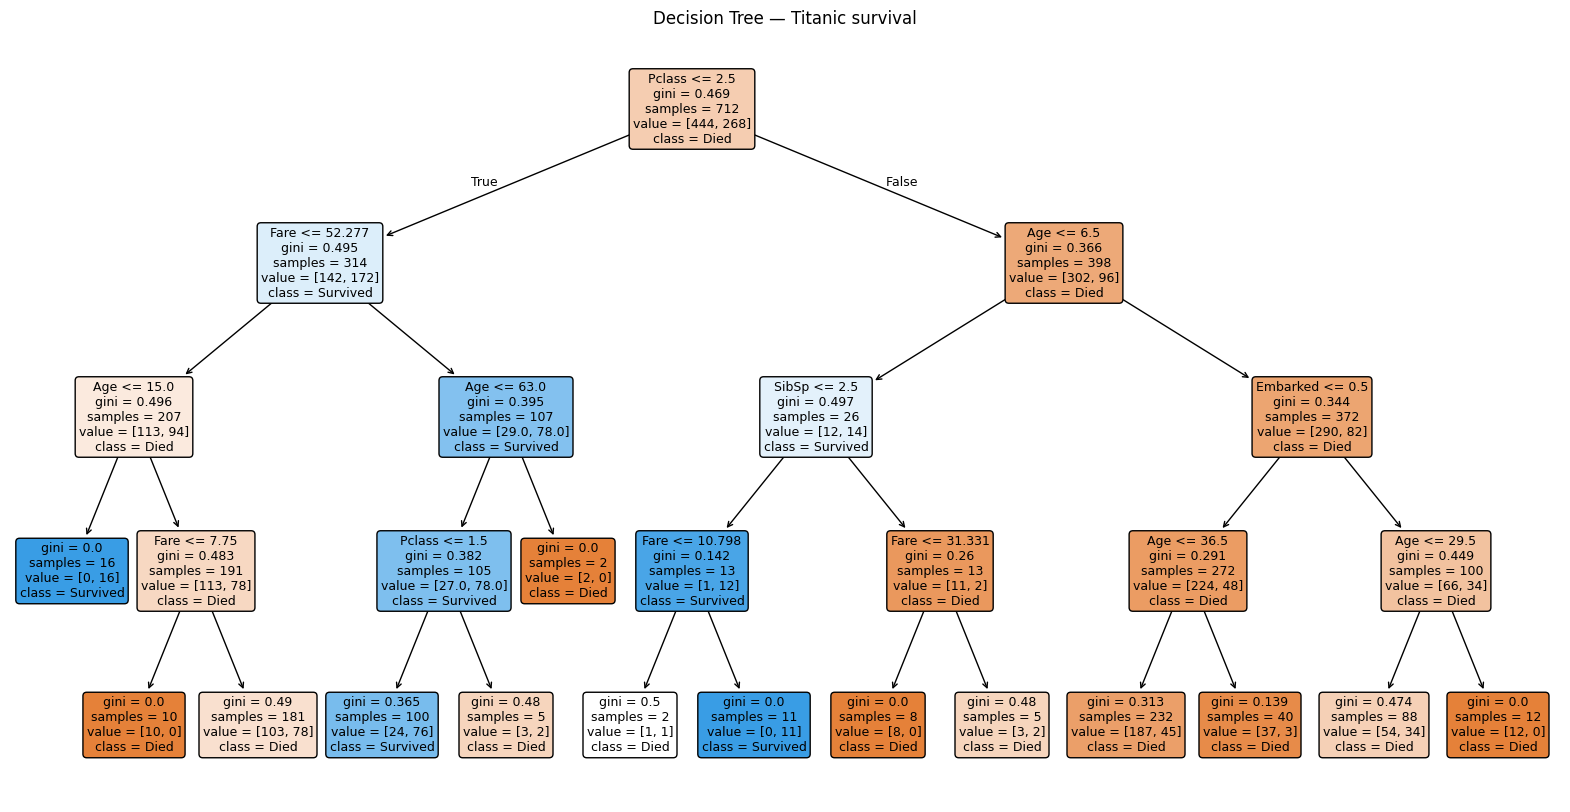

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(dt,filled=True,rounded=True,feature_names=features , class_names=['Died','Survived'], fontsize=9)
plt.title('Decision Tree — Titanic survival')
plt.show()